<a href="https://colab.research.google.com/github/Shubh12005/Quantum-Simulation/blob/main/Grover's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.8 MB/s eta 0:00:00
Target password: 1111

Grover Circuit:

     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐               ┌───┐»
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤       │  ├───┤├───┤            │  ├───┤├───┤            │  ├───┤»
q_1: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤       │  ├───┤├───┤            │  ├───┤├───┤            │  ├───┤»
q_2: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤»
q_3: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
c: 4/══════════════════════════════════════════════════════════════════════»
                                                                           »
«     ┌───┐               ┌───┐┌─

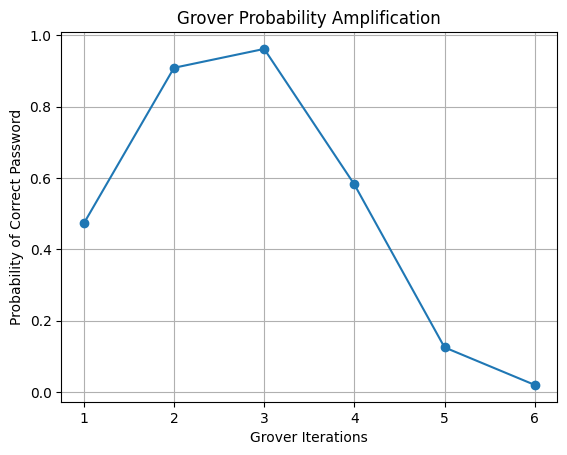

In [ ]:
import sys
!{sys.executable} -m pip install qiskit qiskit-aer

# ============================================================
# Quantum Password Recovery using Grover's Algorithm
# Author: (Your Name)
# Description:
#   Educational simulation of password search using Grover's
#   quantum search algorithm on a constrained keyspace.
# ============================================================

from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Create equal superposition
# ------------------------------------------------------------
def initialize_superposition(qc, n):
    for i in range(n):
        qc.h(i)


# ------------------------------------------------------------
# Oracle: Phase flip for the correct password
# ------------------------------------------------------------
def grover_oracle(qc, password):
    """
    password: string (e.g. '1011')
    """
    n = len(password)

    # Apply X to qubits corresponding to 0s
    for i, bit in enumerate(password):
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z (implemented using H + MCX + H)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Undo X gates
    for i, bit in enumerate(password):
        if bit == '0':
            qc.x(i)


# ------------------------------------------------------------
# Diffusion operator (Inversion about the mean)
# ------------------------------------------------------------
def grover_diffuser(qc, n):
    qc.h(range(n))
    qc.x(range(n))

    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    qc.x(range(n))
    qc.h(range(n))


# ------------------------------------------------------------
# Build Grover circuit
# ------------------------------------------------------------
def grover_circuit(password):
    n = len(password)
    qc = QuantumCircuit(n, n)

    # Step 1: Superposition
    initialize_superposition(qc, n)

    # Optimal number of Grover iterations
    iterations = int(np.floor((np.pi / 4) * np.sqrt(2 ** n)))

    # Step 2: Grover iterations
    for _ in range(iterations):
        grover_oracle(qc, password)
        grover_diffuser(qc, n)

    # Step 3: Measurement
    qc.measure(range(n), range(n))
    return qc, iterations


# ------------------------------------------------------------
# Run simulation
# ------------------------------------------------------------
def run_grover(password):
    qc, iterations = grover_circuit(password)
    backend = Aer.get_backend("qasm_simulator")
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1024)
    result = job.result()
    counts = result.get_counts()
    print("\nGrover Circuit:\n")
    print(qc.draw())
    print(f"\nGrover iterations used: {iterations}")
    print("\nMeasurement Results:")
    print(counts)

    plot_histogram(counts)
    plt.show()


# ------------------------------------------------------------
# Probability amplification visualization
# ------------------------------------------------------------
def probability_amplification(password):
    n = len(password)
    backend = Aer.get_backend("statevector_simulator")

    probs = []
    iterations_range = range(1, int(np.sqrt(2 ** n)) + 3)

    for i in iterations_range:
        qc = QuantumCircuit(n)
        initialize_superposition(qc, n)

        for _ in range(i):
            grover_oracle(qc, password)
            grover_diffuser(qc, n)

        compiled = transpile(qc, backend)
        state = backend.run(compiled).result().get_statevector()

        index = int(password, 2)
        prob = abs(state[index]) ** 2
        probs.append(prob)

    plt.plot(iterations_range, probs, marker='o')
    plt.xlabel("Grover Iterations")
    plt.ylabel("Probability of Correct Password")
    plt.title("Grover Probability Amplification")
    plt.grid()
    plt.show()



# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------
if __name__ == "__main__":
    # Change password length here (2, 3, or 4 bits recommended)
    PASSWORD = "1111"   # 4-bit password

    print("Target password:", PASSWORD)
    run_grover(PASSWORD)
    probability_amplification(PASSWORD)
